# Mini-Project 3
## Lecture 8 - Computer Arithmetic & Numerical Accuracy
### Milestone 1

In [1]:
# Packages
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Adds mandelbrot-nsc to sys.path so lecture_files can be imported
sys.path.append(str(Path("..").resolve()))

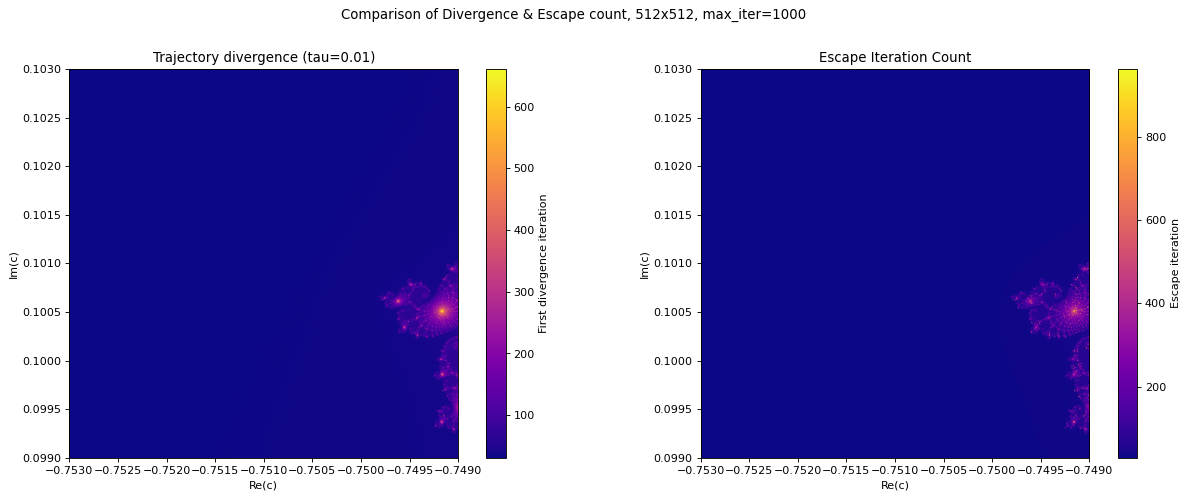

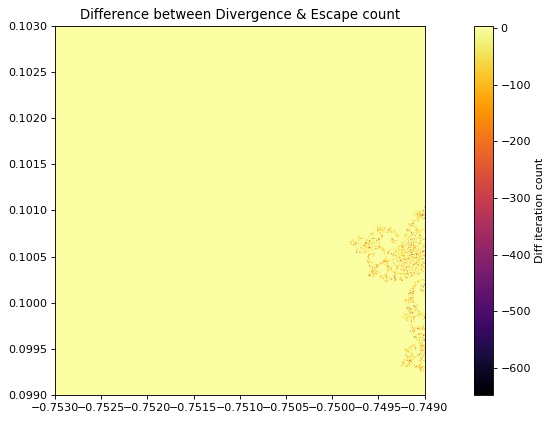

Pixels diverging before max_iter: 262144
Total pixels: 262144
The fraction of pixels diverging before max_iter: 1.00


In [2]:
import lecture_py_files.mandelbrot_8 as mb8 

N = 512
x_dim = (-0.7530, -0.7490)
y_dim = (0.0990, 0.1030)
#x_dim = (-0.750, -0.7490)
#y_dim = (0.0990, 0.1010)
max_iter = 1000
tau = 0.01

# Plot trajectory and escape count
diverge = mb8.mandelbrot_trajectory_divergence(N=N, x_dim=x_dim, y_dim=y_dim, max_iter=max_iter, tau=tau)
escape = mb8.mandelbrot_escape_count(N=N, x_dim=x_dim, y_dim=y_dim, max_iter=max_iter)


fig, axes = plt.subplots(1, 2, figsize=(16,6), dpi=80)
im0 = axes[0].imshow(diverge, extent=[x_dim[0], x_dim[1], y_dim[0], y_dim[1]], cmap='plasma', origin='lower', aspect='equal')
axes[0].set_title(f'Trajectory divergence (tau={tau})')
axes[0].set_xlabel('Re(c)')
axes[0].set_ylabel('Im(c)')
fig.colorbar(im0, ax=axes[0], label='First divergence iteration')
im1 = axes[1].imshow(escape, extent=[x_dim[0], x_dim[1], y_dim[0], y_dim[1]], cmap='plasma', origin='lower', aspect='equal')
axes[1].set_title('Escape Iteration Count')
axes[1].set_xlabel('Re(c)')
axes[1].set_ylabel('Im(c)')
fig.colorbar(im1, ax=axes[1], label='Escape iteration')
plt.suptitle(f'Comparison of Divergence & Escape count, {N}x{N}, {max_iter=}', y=1.02)
plt.tight_layout()
plt.show()

# Inspecting difference between diverge and escape
diff = diverge - escape
count = np.sum(diff < 0)

plt.figure(figsize=(16,6), dpi=80)
plt.imshow(diff, extent=[x_dim[0], x_dim[1], y_dim[0], y_dim[1]], cmap='inferno', origin='lower', aspect='equal')
plt.colorbar(label='Diff iteration count')
plt.title(f'Difference between Divergence & Escape count')

plt.show()

#Fraction diverging before max_iter
count = np.sum(diverge < max_iter)
pixels = N**2
fraction = count / (pixels)
print(f'Pixels diverging before max_iter: {count}')
print(f'Total pixels: {pixels}')
print(f'The fraction of pixels diverging before max_iter: {fraction:.2f}')    

Observations to make:

- What fraction of pixels diverge before max iter?
  
    The fraction of pixels diverging before max_iter is 0.86 (for the full frame):
    ```python
    x_dim = (-2.5, 1.0)
    y_dim = (-1.5, 1.5)
    ```

- Where do trajectories diverge early? Compare visually to the escape-count map.
  
    Early divergence appears in the dark regions outside the Mandelbrot set and along its boundary filaments. These are exactly the areas where orbits escape quickly rather than staying bounded. When inspecting the difference between the trajectories and the escape count, the trajectories is seen to diverge earliest in the boundaries where the escape count is high.

- Does early divergence correlate with high escape iteration counts?
  
    It correlates inversely. Early divergence corresponds to low escape iteration counts. Conversely, the bright yellow regions (high iteration counts) indicate points that remain bounded much longer (inside or near the Mandelbrot set), which does not have early divergence.

### Milestone 2

n_base=array([[30., 30., 30., ..., 34., 34., 34.],
       [30., 30., 30., ..., 34., 34., 34.],
       [30., 30., 30., ..., 34., 34., 34.],
       ...,
       [29., 29., 29., ..., 31., 31., 31.],
       [29., 29., 29., ..., 31., 31., 31.],
       [29., 29., 29., ..., 31., 31., 31.]], shape=(512, 512))


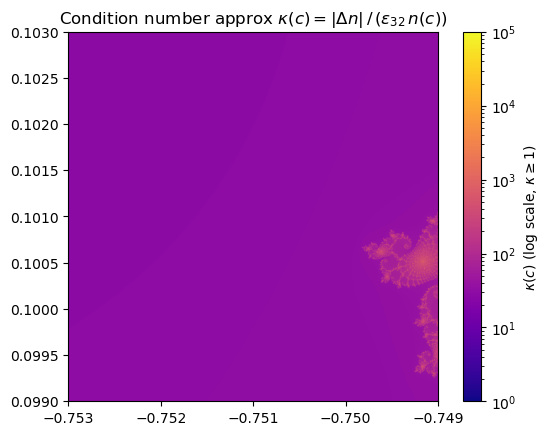

In [3]:
import lecture_py_files.mandelbrot_8 as mb8 

N = 512
x_dim = (-0.7530, -0.7490)
y_dim = (0.0990, 0.1030)
max_iter = 1000

mb8.mandelbrot_sensitivity_map(N=N, max_iter=max_iter, x_dim=x_dim, y_dim=y_dim)

Observations:
- Where is κ largest? Does it match the boundary in M1?
  
    κ is largest at the boundaries between the interior pixels and the exterior as seen on the plot. Therefore it matches the boundaries from M1.
    Furthermore, κ is also large at various pixels in the exterior of the plot.
  
- What is κ for interior pixels (n = max iter)?

    For interior pixels the κ is calculated to $\kappa(c) = \frac{|\Delta n|}{\varepsilon_{32} \cdot n(c)}, \Delta n = n(c+ \delta) - n(c)$.
    Therefore, if $n = \text{max\_iter}$, then $\kappa(c) = \frac{0}{\varepsilon_{32} \cdot max_iter)}$. This means that $\kappa$ mostly collapse to 0, while meaningful structure only appears near the boundary where $\Delta n \neq 0$.

- Comparison of M1 and M2 maps:
  
    Visually comparing the M1 and M2 maps, shows the same seahorse valley map. The exterior region, with low divergence count, low escape count and low $\kappa$.
    At the boundaries $\kappa$ is higly sensitive having values of $\kappa >> 1$, while at the boundaries the divergence count and escape count, transition between low and high, which results in the maps being visually equal.

# Lecture 9 - Testing & Documentation

## Milestone 1 - Pass Count
Record pass count and coverage % in your performance notebook

The pass count is 13 out of 17 tests. The fails are caused by the naive approach, which have other values in the result mandelbrot than 1, being 0 instead. Visually, the result still looks like the numpy result, but the individual pixels are mostly different by a low margin as seen by assert 0 == 1, which shows the failure of the test.

Another failure is the comparison between numpy and naive implementation. This failure is because the numpy implementation does not have a speedup of 10x compared to the naive implementation.

In [4]:
from pathlib import Path
import subprocess

result = subprocess.run(
    [
        "pytest",
        "lecture_py_files/test_mandelbrot.py",
        "-v",
        "--tb=no",      # removes long tracebacks
        "-rF"           # show only failed tests summary
    ],
    cwd=Path("..").resolve(),
    capture_output=True,
    text=True
)

print(result.stdout)

============================= test session starts =============================
platform win32 -- Python 3.11.14, pytest-9.0.2, pluggy-1.6.0 -- C:\Users\mathi\miniforge3\envs\nsc2026\python.exe
cachedir: .pytest_cache
rootdir: C:\UNI\8.Semester\numerical_scientific_computing\mandelbrot-nsc
plugins: anyio-4.12.1, cov-7.1.0
collecting ... collected 17 items

lecture_py_files/test_mandelbrot.py::test_numba_naive_point_matches[0j-100-100-mandelbrot_point_naive] PASSED [  5%]
lecture_py_files/test_mandelbrot.py::test_numba_naive_point_matches[0j-100-100-mandelbrot_point_numba] PASSED [ 11%]
lecture_py_files/test_mandelbrot.py::test_numba_naive_point_matches[(5+0j)-100-1-mandelbrot_point_naive] FAILED [ 17%]
lecture_py_files/test_mandelbrot.py::test_numba_naive_point_matches[(5+0j)-100-1-mandelbrot_point_numba] PASSED [ 23%]
lecture_py_files/test_mandelbrot.py::test_numba_naive_point_matches[(-2.5+0j)-100-1-mandelbrot_point_naive] FAILED [ 29%]
lecture_py_files/test_mandelbrot.py::test_numba

## Milestone 1 - Coverage Percentage

The coverage % is seen below the code.

In [8]:
result = subprocess.run(
    [
        "pytest",
        "lecture_py_files/test_mandelbrot.py",
        "--cov=.", 
        "-v",
        "--tb=no"      # removes long tracebacks
    ],
    cwd=Path("..").resolve(),
    capture_output=True,
    text=True
)

print(result.stdout)

============================= test session starts =============================
platform win32 -- Python 3.11.14, pytest-9.0.2, pluggy-1.6.0 -- C:\Users\mathi\miniforge3\envs\nsc2026\python.exe
cachedir: .pytest_cache
rootdir: C:\UNI\8.Semester\numerical_scientific_computing\mandelbrot-nsc
plugins: anyio-4.12.1, cov-7.1.0
collecting ... collected 17 items

lecture_py_files/test_mandelbrot.py::test_numba_naive_point_matches[0j-100-100-mandelbrot_point_naive] PASSED [  5%]
lecture_py_files/test_mandelbrot.py::test_numba_naive_point_matches[0j-100-100-mandelbrot_point_numba] PASSED [ 11%]
lecture_py_files/test_mandelbrot.py::test_numba_naive_point_matches[(5+0j)-100-1-mandelbrot_point_naive] FAILED [ 17%]
lecture_py_files/test_mandelbrot.py::test_numba_naive_point_matches[(5+0j)-100-1-mandelbrot_point_numba] PASSED [ 23%]
lecture_py_files/test_mandelbrot.py::test_numba_naive_point_matches[(-2.5+0j)-100-1-mandelbrot_point_naive] FAILED [ 29%]
lecture_py_files/test_mandelbrot.py::test_numba